# 12 · Extensión híbrida multimodal: Pareto + KNN

Este notebook añade una extensión experimental con **KNN** al recomendador desarrollado en los notebooks anteriores.

El sistema principal sigue buscando el equilibrio entre precio de la vivienda y tiempo de desplazamiento. **KNN** no sustituye este método, sino que se usa para encontrar barrios parecidos a una recomendación ya obtenida.

La comparación se sigue haciendo por: ***barrio × destino × modo de transporte***

Los modos *TRANSIT, WALK, BICYCLE y CAR* se analizan por separado y no se mezclan dentro de **KNN**.

## 12.1 Preguntas de análisis

Se estudian cuatro cuestiones:

1. **Similitud local:** ¿Qué barrios son más próximos a la recomendación personalizada de cada perfil dentro de la misma combinación *destino–modo*?
2. **Coste de imponer eficiencia:** ¿Cuánto aumenta la distancia **KNN** cuando la búsqueda se restringe a alternativas Pareto?
3. **Sensibilidad a *k*:** ¿Cómo cambian las métricas al pedir 3, 5, 7 o 10 alternativas?
4. **Aporte de características residenciales:** ¿Cambian los vecinos cuando, además de precio y tiempo, se incorporan variables de vivienda disponibles?

**KNN** no se plantea como modelo predictivo ni como estimador de satisfacción del usuario. Su función es recuperar alternativas similares de forma reproducible.


## 12.2 Criterio metodológico

Se separan dos tipos de evidencia:

- **Validaciones estructurales**: Deben cumplirse siempre
- **Indicadores empíricos**: Describen lo observado sin forzar resultados favorables

Que *Pareto_KNN* devuelva un 100 % de alternativas Pareto es una consecuencia de su definición, no un descubrimiento experimental.

La comparación entre *KNN_global* y *Pareto_KNN* utiliza el **mismo número efectivo de vecinos** en cada escenario. Si el frente de Pareto contiene menos de *k* alternativas distintas de la referencia, ambas estrategias se comparan usando ese número menor. Así se evita favorecer artificialmente a una estrategia por devolver listas de distinto tamaño.


## 12.3 Librerías y configuración


In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

EXPECTED_MODES = {
    "TRANSIT": "Transporte público",
    "WALK": "A pie",
    "BICYCLE": "Bicicleta",
    "CAR": "Coche",
}

EXPECTED_PROFILE_WEIGHTS = {
    "price_priority": (0.75, 0.25),
    "balanced": (0.50, 0.50),
    "time_priority": (0.25, 0.75),
}

GROUP_KEY = ["destination_id", "transport_mode"]
ALTERNATIVE_KEY = ["zone_key", "destination_id", "transport_mode"]
SCENARIO_KEY = ["destination_id", "transport_mode", "profile_id"]

PRICE_COLUMN = "price_m2_for_recommender"
TIME_COLUMN = "commute_daily_minutes"

DEFAULT_K = 5
K_VALUES = [3, 5, 7, 10]
FLOAT_TOL = 1e-10


## 12.4 Localización del proyecto y contrato con notebooks anteriores

Se utilizan cuatro salidas ya validadas:

- *pareto_by_destination_mode.csv*: notebook 08
- *recommendation_profiles.csv*: notebook 09
- *profile_recommendation_comparison_by_destination_mode.csv*: notebook 09
- *final_multimodal_validation_report.csv*: notebook 11

El informe del notebook 11 actúa como contrato de entrada- Si el *pipeline* principal no superó sus validaciones estructurales, esta extensión se detiene.


In [2]:
def find_project_root() -> Path:
    current = Path.cwd().resolve()
    required = Path("data") / "results" / "pareto_by_destination_mode.csv"

    for candidate in [current, *current.parents]:
        if (candidate / required).exists():
            return candidate

    raise FileNotFoundError(
        "No se ha localizado la raíz del proyecto. "
        "Ejecuta primero los notebooks 08–11 y abre este cuaderno "
        "desde la carpeta del proyecto o desde notebooks/."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "data" / "results"

PARETO_PATH = RESULTS_DIR / "pareto_by_destination_mode.csv"
PROFILES_PATH = RESULTS_DIR / "recommendation_profiles.csv"
PROFILE_RECOMMENDATIONS_PATH = (
    RESULTS_DIR / "profile_recommendation_comparison_by_destination_mode.csv"
)
PIPELINE_VALIDATION_PATH = (
    RESULTS_DIR / "final_multimodal_validation_report.csv"
)
PIPELINE_SUMMARY_PATH = RESULTS_DIR / "final_multimodal_summary.csv"

OUTPUT_PATHS = {
    "candidate_pool_summary": RESULTS_DIR / "knn12_multimodal_candidate_pool_summary.csv",
    "feature_audit": RESULTS_DIR / "knn12_multimodal_feature_audit.csv",
    "anchors": RESULTS_DIR / "knn12_multimodal_anchors.csv",
    "availability": RESULTS_DIR / "knn12_multimodal_availability_audit.csv",
    "neighbors_default": RESULTS_DIR / "knn12_multimodal_neighbors_k5.csv",
    "evaluation_default": RESULTS_DIR / "knn12_multimodal_evaluation_k5.csv",
    "strategy_comparison": RESULTS_DIR / "knn12_multimodal_strategy_comparison.csv",
    "strategy_overlap": RESULTS_DIR / "knn12_multimodal_strategy_overlap.csv",
    "mode_summary": RESULTS_DIR / "knn12_multimodal_mode_summary.csv",
    "profile_overlap": RESULTS_DIR / "knn12_multimodal_profile_overlap.csv",
    "feature_space_overlap": RESULTS_DIR / "knn12_multimodal_feature_space_overlap.csv",
    "sensitivity_neighbors": RESULTS_DIR / "knn12_multimodal_neighbors_sensitivity.csv",
    "sensitivity_summary": RESULTS_DIR / "knn12_multimodal_sensitivity_summary.csv",
    "empirical_indicators": RESULTS_DIR / "knn12_multimodal_empirical_indicators.csv",
    "validation_report": RESULTS_DIR / "knn12_multimodal_validation_report.csv",
    "final_summary": RESULTS_DIR / "knn12_multimodal_summary.csv",
}

print("Raíz del proyecto:", PROJECT_ROOT)
print("Directorio de resultados:", RESULTS_DIR)


Raíz del proyecto: /home/aclaver/TFG-INFO
Directorio de resultados: /home/aclaver/TFG-INFO/data/results


## 12.5 Carga y validación inicial


In [3]:
required_paths = [
    PARETO_PATH,
    PROFILES_PATH,
    PROFILE_RECOMMENDATIONS_PATH,
    PIPELINE_VALIDATION_PATH,
]

missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    raise FileNotFoundError(
        "Faltan salidas necesarias de los notebooks anteriores:\n"
        + "\n".join(
            f"- {path.relative_to(PROJECT_ROOT)}"
            for path in missing_paths
        )
    )

data = pd.read_csv(PARETO_PATH)
profiles = pd.read_csv(PROFILES_PATH)
profile_recommendations = pd.read_csv(PROFILE_RECOMMENDATIONS_PATH)
pipeline_validation = pd.read_csv(PIPELINE_VALIDATION_PATH)

pipeline_summary = (
    pd.read_csv(PIPELINE_SUMMARY_PATH, index_col=0)
    if PIPELINE_SUMMARY_PATH.exists()
    else pd.DataFrame()
)

print("Pareto 08:", data.shape)
print("Perfiles 09:", profiles.shape)
print("Recomendaciones 09:", profile_recommendations.shape)
print("Validaciones 11:", pipeline_validation.shape)


Pareto 08: (1457, 158)
Perfiles 09: (3, 4)
Recomendaciones 09: (36, 21)
Validaciones 11: (16, 5)


In [4]:
def coerce_bool_series(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    normalized = series.astype(str).str.strip().str.lower()
    mapping = {
        "true": True, "1": True, "yes": True, "si": True, "sí": True,
        "false": False, "0": False, "no": False,
    }
    result = normalized.map(mapping)

    if result.isna().any():
        bad_values = sorted(
            series.loc[result.isna()].astype(str).unique().tolist()
        )
        raise ValueError(
            "No se ha podido interpretar una columna booleana. "
            f"Valores problemáticos: {bad_values[:10]}"
        )

    return result.astype(bool)


required_data_columns = {
    "zone_key",
    "neighborhood_name",
    "district_name",
    "destination_id",
    "destination_name",
    "transport_mode",
    "transport_mode_label",
    PRICE_COLUMN,
    TIME_COLUMN,
    "is_pareto",
    "price_normalized",
    "time_normalized",
}

required_profile_columns = {
    "profile_id",
    "profile_name",
    "price_weight",
    "time_weight",
}

required_recommendation_columns = {
    "destination_id",
    "destination_name",
    "transport_mode",
    "transport_mode_label",
    "profile_id",
    "profile_name",
    "price_weight",
    "time_weight",
    "zone_key",
    "status",
}

missing_data_columns = sorted(required_data_columns - set(data.columns))
missing_profile_columns = sorted(required_profile_columns - set(profiles.columns))
missing_recommendation_columns = sorted(
    required_recommendation_columns - set(profile_recommendations.columns)
)

if missing_data_columns:
    raise KeyError(
        "Faltan columnas en pareto_by_destination_mode.csv: "
        f"{missing_data_columns}"
    )

if missing_profile_columns:
    raise KeyError(
        "Faltan columnas en recommendation_profiles.csv: "
        f"{missing_profile_columns}"
    )

if missing_recommendation_columns:
    raise KeyError(
        "Faltan columnas en las recomendaciones del notebook 09: "
        f"{missing_recommendation_columns}"
    )

data["is_pareto"] = coerce_bool_series(data["is_pareto"])

for column in [
    PRICE_COLUMN,
    TIME_COLUMN,
    "price_normalized",
    "time_normalized",
]:
    data[column] = pd.to_numeric(data[column], errors="coerce")

for frame in [profiles, profile_recommendations]:
    frame["price_weight"] = pd.to_numeric(
        frame["price_weight"], errors="coerce"
    )
    frame["time_weight"] = pd.to_numeric(
        frame["time_weight"], errors="coerce"
    )

if "validation_type" in pipeline_validation.columns:
    structural_pipeline_rows = pipeline_validation.loc[
        pipeline_validation["validation_type"].astype(str).eq("structural")
    ].copy()
else:
    structural_pipeline_rows = pipeline_validation.copy()

structural_pipeline_rows["passed"] = coerce_bool_series(
    structural_pipeline_rows["passed"]
)

if structural_pipeline_rows.empty:
    raise ValueError(
        "El informe del notebook 11 no contiene validaciones estructurales."
    )

if not structural_pipeline_rows["passed"].all():
    failed = structural_pipeline_rows.loc[
        ~structural_pipeline_rows["passed"]
    ]
    display(failed)
    raise AssertionError(
        "El pipeline principal no superó todas las validaciones "
        "estructurales del notebook 11."
    )

print(
    "Contrato del notebook 11 superado:",
    f"{int(structural_pipeline_rows['passed'].sum())}/"
    f"{len(structural_pipeline_rows)}",
)


Contrato del notebook 11 superado: 15/15


### Lectura del contrato

La extensión KNN parte únicamente de alternativas que ya llegaron al análisis de Pareto del notebook 08. Por ello, ni el precio ni el tiempo se imputan

Las variables residenciales auxiliares sí pueden contener valores ausentes. Si se utilizan en **KNN**, su imputación se limita a la construcción de la distancia de similitud y se realiza con la mediana del grupo *destino–modo*.


In [5]:
duplicate_alternatives = int(
    data.duplicated(subset=ALTERNATIVE_KEY).sum()
)

observed_modes = set(data["transport_mode"].astype(str).unique())

group_catalog = (
    data[
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(GROUP_KEY)
    .reset_index(drop=True)
)

core_missing = int(
    data[
        [
            PRICE_COLUMN,
            TIME_COLUMN,
            "price_normalized",
            "time_normalized",
        ]
    ].isna().any(axis=1).sum()
)

nonpositive_price = int((data[PRICE_COLUMN] <= 0).sum())
nonpositive_time = int((data[TIME_COLUMN] <= 0).sum())

print("Alternativas:", len(data))
print("Barrios:", data["zone_key"].nunique())
print("Destinos:", data["destination_id"].nunique())
print("Modos:", data["transport_mode"].nunique())
print("Grupos destino-modo:", len(group_catalog))
print("Duplicados de alternativa:", duplicate_alternatives)
print("Filas con objetivos/normalizaciones ausentes:", core_missing)
print("Precios no positivos:", nonpositive_price)
print("Tiempos no positivos:", nonpositive_time)


Alternativas: 1457
Barrios: 129
Destinos: 3
Modos: 4
Grupos destino-modo: 12
Duplicados de alternativa: 0
Filas con objetivos/normalizaciones ausentes: 0
Precios no positivos: 0
Tiempos no positivos: 0


## 12.6 Revalidación independiente de Pareto


In [6]:
def pareto_mask_2d(
    price: pd.Series,
    time: pd.Series,
) -> np.ndarray:
    values = np.column_stack(
        [
            pd.to_numeric(price, errors="coerce").to_numpy(dtype=float),
            pd.to_numeric(time, errors="coerce").to_numpy(dtype=float),
        ]
    )

    if not np.isfinite(values).all():
        raise ValueError("Pareto ha recibido valores no finitos.")

    n = len(values)
    efficient = np.ones(n, dtype=bool)

    for i in range(n):
        dominated_by_other = np.any(
            np.all(values <= values[i], axis=1)
            & np.any(values < values[i], axis=1)
        )

        if dominated_by_other:
            efficient[i] = False

    return efficient


data = data.copy()
data["is_pareto_knn12"] = False

for _, indices in data.groupby(GROUP_KEY, sort=True).groups.items():
    group = data.loc[indices]
    data.loc[indices, "is_pareto_knn12"] = pareto_mask_2d(
        group[PRICE_COLUMN],
        group[TIME_COLUMN],
    )

pareto_mismatches = int(
    (data["is_pareto"] != data["is_pareto_knn12"]).sum()
)

candidate_pool_summary = (
    data.groupby(
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        alternatives=("zone_key", "size"),
        pareto_alternatives=("is_pareto_knn12", "sum"),
    )
)

candidate_pool_summary["pareto_pool_reduction_pct"] = (
    100
    * (
        1
        - candidate_pool_summary["pareto_alternatives"]
        / candidate_pool_summary["alternatives"]
    )
)

display(candidate_pool_summary)
print("Discrepancias respecto al Pareto del notebook 08:", pareto_mismatches)


,destination_id,destination_name,transport_mode,transport_mode_label,alternatives,pareto_alternatives,pareto_pool_reduction_pct
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,129,14,89.1473
1,DEST_001,Puerta del Sol,CAR,Coche,121,14,88.4298
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público,119,13,89.0756
3,DEST_001,Puerta del Sol,WALK,A pie,128,16,87.5000
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta,129,16,87.5969
5,DEST_002,Nuevos Ministerios,CAR,Coche,121,18,85.1240
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público,124,10,91.9355
7,DEST_002,Nuevos Ministerios,WALK,A pie,129,18,86.0465
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta,129,4,96.8992
9,DEST_003,UC3M Campus de Leganés,CAR,Coche,121,4,96.6942


Discrepancias respecto al Pareto del notebook 08: 0


## 12.7 Perfiles y referencias personalizadas

Las referencias **KNN** son las 36 recomendaciones top 1 del notebook 09: ***3 destinos x 4  modos x 3 perfiles = 36 recomendaciones***

Para asegurar la continuidad del *pipeline*, se reconstruye de forma independiente el ganador de cada perfil y se compara con la recomendación almacenada.


In [7]:
profile_contract_rows = []

for profile_id, (
    expected_price_weight,
    expected_time_weight,
) in EXPECTED_PROFILE_WEIGHTS.items():
    matches = profiles.loc[
        profiles["profile_id"].astype(str).eq(profile_id)
    ]

    if len(matches) != 1:
        profile_contract_rows.append(
            {
                "profile_id": profile_id,
                "passed": False,
                "detail": f"Filas encontradas: {len(matches)}",
            }
        )
        continue

    row = matches.iloc[0]

    passed = (
        np.isclose(row["price_weight"], expected_price_weight)
        and np.isclose(row["time_weight"], expected_time_weight)
        and np.isclose(
            row["price_weight"] + row["time_weight"],
            1.0,
        )
    )

    profile_contract_rows.append(
        {
            "profile_id": profile_id,
            "passed": bool(passed),
            "detail": (
                f"pesos=({row['price_weight']:.2f}, "
                f"{row['time_weight']:.2f})"
            ),
        }
    )

profile_contract = pd.DataFrame(profile_contract_rows)
display(profile_contract)


,profile_id,passed,detail
0,price_priority,True,"pesos=(0.75, 0.25)"
1,balanced,True,"pesos=(0.50, 0.50)"
2,time_priority,True,"pesos=(0.25, 0.75)"


In [8]:
def independently_select_anchor(
    group: pd.DataFrame,
    price_weight: float,
    time_weight: float,
) -> pd.Series:
    front = group.loc[group["is_pareto_knn12"]].copy()

    if front.empty:
        raise ValueError("No existe frente de Pareto en un grupo.")

    front["anchor_score_knn12"] = (
        price_weight * front["price_normalized"]
        + time_weight * front["time_normalized"]
    )

    sort_columns = ["anchor_score_knn12"]
    ascending = [True]

    if "price_reliability_score" in front.columns:
        front["price_reliability_score"] = pd.to_numeric(
            front["price_reliability_score"],
            errors="coerce",
        )
        sort_columns.append("price_reliability_score")
        ascending.append(False)

    sort_columns.extend([PRICE_COLUMN, TIME_COLUMN, "zone_key"])
    ascending.extend([True, True, True])

    return (
        front.sort_values(
            sort_columns,
            ascending=ascending,
            na_position="last",
        )
        .iloc[0]
    )


recommended_anchors = profile_recommendations.loc[
    profile_recommendations["status"].astype(str).eq("recommended")
].copy()

anchor_rows = []

for _, rec in recommended_anchors.iterrows():
    group = data.loc[
        data["destination_id"].astype(str).eq(str(rec["destination_id"]))
        & data["transport_mode"].astype(str).eq(str(rec["transport_mode"]))
    ].copy()

    independent = independently_select_anchor(
        group=group,
        price_weight=float(rec["price_weight"]),
        time_weight=float(rec["time_weight"]),
    )

    stored_zone_key = str(rec["zone_key"])
    independent_zone_key = str(independent["zone_key"])

    anchor_rows.append(
        {
            "destination_id": rec["destination_id"],
            "destination_name": rec["destination_name"],
            "transport_mode": rec["transport_mode"],
            "transport_mode_label": rec["transport_mode_label"],
            "profile_id": rec["profile_id"],
            "profile_name": rec["profile_name"],
            "price_weight": float(rec["price_weight"]),
            "time_weight": float(rec["time_weight"]),
            "anchor_zone_key": stored_zone_key,
            "anchor_neighborhood_name": (
                rec["neighborhood_name"]
                if "neighborhood_name" in rec.index
                else independent["neighborhood_name"]
            ),
            "anchor_price_m2": float(independent[PRICE_COLUMN]),
            "anchor_commute_daily_minutes": float(independent[TIME_COLUMN]),
            "anchor_is_pareto": bool(independent["is_pareto_knn12"]),
            "independent_zone_key": independent_zone_key,
            "anchor_matches_independent_reconstruction": (
                stored_zone_key == independent_zone_key
            ),
        }
    )

anchors = pd.DataFrame(anchor_rows)

display(anchors.sort_values(SCENARIO_KEY))

print(
    "Referencias coincidentes con la reconstrucción independiente:",
    f"{int(anchors['anchor_matches_independent_reconstruction'].sum())}/"
    f"{len(anchors)}",
)


,destination_id,destination_name,transport_mode,transport_mode_label,profile_id,profile_name,price_weight,time_weight,anchor_zone_key,anchor_neighborhood_name,anchor_price_m2,anchor_commute_daily_minutes,anchor_is_pareto,independent_zone_key,anchor_matches_independent_reconstruction
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,balanced,Perfil equilibrado,0.5000,0.5000,MAD-102,Puerta del Ángel,"4,033.3000",30.2667,True,MAD-102,True
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,0.7500,0.2500,MAD-121,Orcasitas,"2,357.5100",73.7167,True,MAD-121,True
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,time_priority,Prioridad al tiempo,0.2500,0.7500,MAD-016,Sol,"7,696.6100",3.7000,True,MAD-016,True
4,DEST_001,Puerta del Sol,CAR,Coche,balanced,Perfil equilibrado,0.5000,0.5000,MAD-134,Palomeras Sureste,"2,701.3600",24.3667,True,MAD-134,True
3,DEST_001,Puerta del Sol,CAR,Coche,price_priority,Prioridad al precio,0.7500,0.2500,MAD-121,Orcasitas,"2,357.5100",28.4167,True,MAD-121,True
5,DEST_001,Puerta del Sol,CAR,Coche,time_priority,Prioridad al tiempo,0.2500,0.7500,MAD-015,Universidad,"7,135.4300",10.0000,True,MAD-015,True
7,DEST_001,Puerta del Sol,TRANSIT,Transporte público,balanced,Perfil equilibrado,0.5000,0.5000,MAD-102,Puerta del Ángel,"4,033.3000",65.1333,True,MAD-102,True
6,DEST_001,Puerta del Sol,TRANSIT,Transporte público,price_priority,Prioridad al precio,0.7500,0.2500,MAD-172,San Cristóbal,"1,909.6000",139.7167,True,MAD-172,True
8,DEST_001,Puerta del Sol,TRANSIT,Transporte público,time_priority,Prioridad al tiempo,0.2500,0.7500,MAD-102,Puerta del Ángel,"4,033.3000",65.1333,True,MAD-102,True
10,DEST_001,Puerta del Sol,WALK,A pie,balanced,Perfil equilibrado,0.5000,0.5000,MAD-102,Puerta del Ángel,"4,033.3000",79.7167,True,MAD-102,True


Referencias coincidentes con la reconstrucción independiente: 36/36


## 12.8 Espacios de características

Se comparan dos espacios de similitud:

- ***objective_only***: precio por m² y tiempo diario;
- ***extended***: precio, tiempo y características residenciales agregadas disponibles con cobertura suficiente.

No se incluye la fiabilidad del precio como característica de similitud, porque describe la calidad del dato y no una propiedad de la vivienda.


In [9]:
OPTIONAL_FEATURE_GROUPS = {
    "surface": [
        "area_m2_median",
        "area_m2_mean",
        "size_median",
        "size_mean",
        "surface_median",
        "surface_mean",
        "sale_size",
        "metros_median",
        "metros_mean",
    ],
    "rooms": [
        "rooms_median",
        "rooms_mean",
        "sale_rooms",
        "habitaciones_median",
        "habitaciones_mean",
    ],
    "bathrooms": [
        "baths_median",
        "baths_mean",
        "sale_baths",
        "banos_median",
        "banos_mean",
    ],
    "elevator": [
        "elevator_ratio",
        "ascensor_ratio",
    ],
    "exterior": [
        "exterior_ratio",
    ],
}

feature_audit_rows = []
selected_optional_features = []

for feature_group, candidates in OPTIONAL_FEATURE_GROUPS.items():
    selected_column = next(
        (column for column in candidates if column in data.columns),
        None,
    )

    if selected_column is None:
        feature_audit_rows.append(
            {
                "feature_group": feature_group,
                "selected_column": None,
                "exists": False,
                "non_missing_pct": 0.0,
                "n_unique": 0,
                "included_extended": False,
                "reason": "No existe ninguna columna candidata.",
            }
        )
        continue

    numeric = pd.to_numeric(
        data[selected_column],
        errors="coerce",
    )

    non_missing_pct = float(
        100 * numeric.notna().mean()
    )

    n_unique = int(
        numeric.nunique(dropna=True)
    )

    included = (
        non_missing_pct >= 70.0
        and n_unique >= 2
    )

    if included:
        data[selected_column] = numeric
        selected_optional_features.append(
            selected_column
        )

    feature_audit_rows.append(
        {
            "feature_group": feature_group,
            "selected_column": selected_column,
            "exists": True,
            "non_missing_pct": non_missing_pct,
            "n_unique": n_unique,
            "included_extended": included,
            "reason": (
                "Incluida."
                if included
                else "Cobertura < 70 % o sin variación suficiente."
            ),
        }
    )

feature_audit = pd.DataFrame(
    feature_audit_rows
)

OBJECTIVE_FEATURES = [
    PRICE_COLUMN,
    TIME_COLUMN,
]

EXTENDED_FEATURES = (
    OBJECTIVE_FEATURES
    + selected_optional_features
)

FEATURE_SPACES = {
    "objective_only": OBJECTIVE_FEATURES,
    "extended": EXTENDED_FEATURES,
}

display(feature_audit)

print(
    "Variables objective_only:",
    OBJECTIVE_FEATURES,
)

print(
    "Variables extended:",
    EXTENDED_FEATURES,
)

,feature_group,selected_column,exists,non_missing_pct,n_unique,included_extended,reason
0,surface,area_m2_median,True,98.3528,92,True,Incluida.
1,rooms,rooms_median,True,98.3528,7,True,Incluida.
2,bathrooms,NaN,False,0.0000,0,False,No existe ninguna columna candidata.
3,elevator,elevator_ratio,True,98.3528,105,True,Incluida.
4,exterior,exterior_ratio,True,98.3528,82,True,Incluida.


Variables objective_only: ['price_m2_for_recommender', 'commute_daily_minutes']
Variables extended: ['price_m2_for_recommender', 'commute_daily_minutes', 'area_m2_median', 'rooms_median', 'elevator_ratio', 'exterior_ratio']


## 12.9 Estandarización por destino y modo

Cada modelo KNN se calcula por separado para cada combinación de destino × modo, para no mezclar escalas de movilidad distintas.

Si falta alguna variable auxiliar, se rellena con la mediana del grupo solo para poder calcular la similitud. El precio y el tiempo, en cambio, ya llegan completos desde el notebook 08 y no se modifican.

Además de la distancia euclídea normal, se calcula una versión ajustada al número de variables: ***Distancia normalizada = distancia euclídea/(número de características)^-2***

Esto no cambia qué vecinos son los más cercanos, pero permite comparar mejor los grupos que usan distinto número de características.


In [10]:
def prepare_group_matrix(
    group: pd.DataFrame,
    feature_cols: list[str],
) -> tuple[np.ndarray, pd.DataFrame]:
    X = group[feature_cols].copy()

    for column in feature_cols:
        X[column] = pd.to_numeric(
            X[column],
            errors="coerce",
        )

        median = X[column].median()

        if pd.isna(median):
            global_median = pd.to_numeric(
                data[column],
                errors="coerce",
            ).median()

            median = (
                float(global_median)
                if pd.notna(global_median)
                else 0.0
            )

        X[column] = X[column].fillna(median)

    if not np.isfinite(X.to_numpy(dtype=float)).all():
        raise ValueError(
            "La matriz KNN contiene valores no finitos "
            "después de la imputación auxiliar."
        )

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, X


def nearest_positions(
    X_scaled: np.ndarray,
    anchor_position: int,
    candidate_positions: list[int],
    k: int,
) -> list[tuple[int, int, float]]:
    candidates = [
        int(position)
        for position in candidate_positions
        if int(position) != int(anchor_position)
    ]

    if k <= 0 or not candidates:
        return []

    n_neighbors = min(int(k), len(candidates))

    model = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="euclidean",
        algorithm="auto",
    )

    model.fit(X_scaled[candidates])

    distances, local_indices = model.kneighbors(
        X_scaled[[anchor_position]],
        return_distance=True,
    )

    results = []

    for rank, (distance, local_index) in enumerate(
        zip(distances[0], local_indices[0]),
        start=1,
    ):
        global_position = candidates[int(local_index)]
        results.append(
            (rank, global_position, float(distance))
        )

    return results


## 12.10 Comparación KNN global vs Pareto + KNN

Para cada *destino–modo–perfil* se usa la misma referencia y el mismo número efectivo de vecinos en las dos estrategias:

- ***KNN_global***: busca entre todas las alternativas comparables del grupo
- ***Pareto_KNN***: busca únicamente entre alternativas Pareto

La referencia nunca puede aparecer como vecina de sí misma.


In [11]:
def top_distance_drivers(
    feature_cols: list[str],
    anchor_vector: np.ndarray,
    neighbor_vector: np.ndarray,
    top_n: int = 3,
) -> str:
    squared_differences = (
        neighbor_vector - anchor_vector
    ) ** 2

    total = float(squared_differences.sum())

    if np.isclose(total, 0.0):
        return "Sin diferencias estandarizadas"

    order = np.argsort(squared_differences)[::-1]
    parts = []

    for position in order[:top_n]:
        share = (
            100
            * squared_differences[position]
            / total
        )
        parts.append(
            f"{feature_cols[position]} ({share:.1f} %)"
        )

    return "; ".join(parts)


def run_knn_experiment(
    data_df: pd.DataFrame,
    anchors_df: pd.DataFrame,
    feature_cols: list[str],
    feature_space: str,
    requested_k: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    neighbor_rows = []
    availability_rows = []

    for (
        destination_id,
        transport_mode,
    ), group_original in data_df.groupby(
        GROUP_KEY,
        sort=True,
    ):
        group = (
            group_original
            .sort_values("zone_key")
            .reset_index(drop=True)
            .copy()
        )

        X_scaled, _ = prepare_group_matrix(
            group,
            feature_cols,
        )

        scenario_anchors = anchors_df.loc[
            anchors_df["destination_id"].astype(str).eq(str(destination_id))
            & anchors_df["transport_mode"].astype(str).eq(str(transport_mode))
        ]

        for _, anchor_info in scenario_anchors.iterrows():
            anchor_matches = group.index[
                group["zone_key"].astype(str).eq(
                    str(anchor_info["anchor_zone_key"])
                )
            ].tolist()

            if len(anchor_matches) != 1:
                raise ValueError(
                    "La referencia no aparece exactamente una vez "
                    "en su grupo destino–modo."
                )

            anchor_position = int(anchor_matches[0])
            anchor_row = group.iloc[anchor_position]

            global_candidates = [
                int(position)
                for position in group.index
                if int(position) != anchor_position
            ]

            pareto_candidates = [
                int(position)
                for position in group.index[
                    group["is_pareto_knn12"]
                ]
                if int(position) != anchor_position
            ]

            comparison_k = min(
                int(requested_k),
                len(global_candidates),
                len(pareto_candidates),
            )

            availability_rows.append(
                {
                    "destination_id": destination_id,
                    "destination_name": anchor_info["destination_name"],
                    "transport_mode": transport_mode,
                    "transport_mode_label": anchor_info["transport_mode_label"],
                    "profile_id": anchor_info["profile_id"],
                    "profile_name": anchor_info["profile_name"],
                    "feature_space": feature_space,
                    "requested_k": int(requested_k),
                    "global_candidates": len(global_candidates),
                    "pareto_candidates": len(pareto_candidates),
                    "comparison_k": int(comparison_k),
                    "full_k_available": bool(
                        comparison_k == int(requested_k)
                    ),
                }
            )

            if comparison_k == 0:
                continue

            candidate_sets = {
                "KNN_global": global_candidates,
                "Pareto_KNN": pareto_candidates,
            }

            for method, candidate_positions in candidate_sets.items():
                neighbors = nearest_positions(
                    X_scaled=X_scaled,
                    anchor_position=anchor_position,
                    candidate_positions=candidate_positions,
                    k=comparison_k,
                )

                for rank, neighbor_position, raw_distance in neighbors:
                    neighbor = group.iloc[neighbor_position]

                    normalized_distance = (
                        raw_distance / np.sqrt(len(feature_cols))
                    )

                    price_delta_pct = (
                        100
                        * (
                            neighbor[PRICE_COLUMN]
                            - anchor_row[PRICE_COLUMN]
                        )
                        / anchor_row[PRICE_COLUMN]
                    )

                    time_delta_pct = (
                        100
                        * (
                            neighbor[TIME_COLUMN]
                            - anchor_row[TIME_COLUMN]
                        )
                        / anchor_row[TIME_COLUMN]
                    )

                    neighbor_rows.append(
                        {
                            "destination_id": destination_id,
                            "destination_name": anchor_info["destination_name"],
                            "transport_mode": transport_mode,
                            "transport_mode_label": anchor_info["transport_mode_label"],
                            "profile_id": anchor_info["profile_id"],
                            "profile_name": anchor_info["profile_name"],
                            "feature_space": feature_space,
                            "method": method,
                            "requested_k": int(requested_k),
                            "comparison_k": int(comparison_k),
                            "neighbor_rank": int(rank),
                            "anchor_zone_key": anchor_info["anchor_zone_key"],
                            "anchor_neighborhood_name": anchor_info["anchor_neighborhood_name"],
                            "neighbor_zone_key": neighbor["zone_key"],
                            "neighbor_neighborhood_name": neighbor["neighborhood_name"],
                            "neighbor_district_name": neighbor["district_name"],
                            "neighbor_is_pareto": bool(neighbor["is_pareto_knn12"]),
                            "raw_knn_distance": float(raw_distance),
                            "normalized_knn_distance": float(normalized_distance),
                            "anchor_price_m2": float(anchor_row[PRICE_COLUMN]),
                            "neighbor_price_m2": float(neighbor[PRICE_COLUMN]),
                            "price_delta_pct": float(price_delta_pct),
                            "anchor_commute_daily_minutes": float(anchor_row[TIME_COLUMN]),
                            "neighbor_commute_daily_minutes": float(neighbor[TIME_COLUMN]),
                            "time_delta_pct": float(time_delta_pct),
                            "top_distance_drivers": top_distance_drivers(
                                feature_cols=feature_cols,
                                anchor_vector=X_scaled[anchor_position],
                                neighbor_vector=X_scaled[neighbor_position],
                            ),
                        }
                    )

    return pd.DataFrame(neighbor_rows), pd.DataFrame(availability_rows)


## 12.11 Ejecución principal (*k = 5*)


In [12]:
neighbors_default, availability_default = run_knn_experiment(
    data_df=data,
    anchors_df=anchors,
    feature_cols=EXTENDED_FEATURES,
    feature_space="extended",
    requested_k=DEFAULT_K,
)

if neighbors_default.empty:
    raise ValueError(
        "La extensión KNN no ha generado ninguna alternativa."
    )

display(availability_default.head(12))
display(neighbors_default.head(12))

print(
    "Escenarios disponibles:",
    availability_default[SCENARIO_KEY].drop_duplicates().shape[0],
)
print("Vecinos generados:", len(neighbors_default))
print(
    "Escenarios con k completo:",
    int(availability_default["full_k_available"].sum()),
    "/",
    len(availability_default),
)


,destination_id,destination_name,transport_mode,transport_mode_label,profile_id,profile_name,feature_space,requested_k,global_candidates,pareto_candidates,comparison_k,full_k_available
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,5,128,13,5,True
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,balanced,Perfil equilibrado,extended,5,128,13,5,True
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,time_priority,Prioridad al tiempo,extended,5,128,13,5,True
3,DEST_001,Puerta del Sol,CAR,Coche,price_priority,Prioridad al precio,extended,5,120,13,5,True
4,DEST_001,Puerta del Sol,CAR,Coche,balanced,Perfil equilibrado,extended,5,120,13,5,True
5,DEST_001,Puerta del Sol,CAR,Coche,time_priority,Prioridad al tiempo,extended,5,120,13,5,True
6,DEST_001,Puerta del Sol,TRANSIT,Transporte público,price_priority,Prioridad al precio,extended,5,118,12,5,True
7,DEST_001,Puerta del Sol,TRANSIT,Transporte público,balanced,Perfil equilibrado,extended,5,118,12,5,True
8,DEST_001,Puerta del Sol,TRANSIT,Transporte público,time_priority,Prioridad al tiempo,extended,5,118,12,5,True
9,DEST_001,Puerta del Sol,WALK,A pie,price_priority,Prioridad al precio,extended,5,127,15,5,True


,destination_id,destination_name,transport_mode,transport_mode_label,profile_id,profile_name,feature_space,method,requested_k,comparison_k,neighbor_rank,anchor_zone_key,anchor_neighborhood_name,neighbor_zone_key,neighbor_neighborhood_name,neighbor_district_name,neighbor_is_pareto,raw_knn_distance,normalized_knn_distance,anchor_price_m2,neighbor_price_m2,price_delta_pct,anchor_commute_daily_minutes,neighbor_commute_daily_minutes,time_delta_pct,top_distance_drivers
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,KNN_global,5,5,1,MAD-121,Orcasitas,MAD-175,Ángeles,Villaverde,False,0.8238,0.3363,"2,357.5100","2,956.0300",25.3878,73.7167,77.7667,5.4940,elevator_ratio (84.4 %); price_m2_for_recommender (11.3 %); area_m2_median (2.4 %)
1,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,KNN_global,5,5,2,MAD-121,Orcasitas,MAD-144,Media Legua,Moratalaz,False,0.8551,0.3491,"2,357.5100","3,876.7200",64.4413,73.7167,56.3333,-23.5813,price_m2_for_recommender (67.6 %); commute_daily_minutes (32.3 %); elevator_ratio (0.1 %)
2,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,KNN_global,5,5,3,MAD-121,Orcasitas,MAD-143,Marroquina,Moratalaz,False,0.9447,0.3857,"2,357.5100","4,301.1700",82.4455,73.7167,72.5167,-1.6279,price_m2_for_recommender (90.6 %); elevator_ratio (8.2 %); area_m2_median (1.1 %)
3,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,KNN_global,5,5,4,MAD-121,Orcasitas,MAD-107,Águilas,Latina,False,1.0039,0.4098,"2,357.5100","3,231.6400",37.0785,73.7167,83.5667,13.3620,exterior_ratio (41.9 %); elevator_ratio (29.3 %); price_m2_for_recommender (16.2 %)
4,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,KNN_global,5,5,5,MAD-121,Orcasitas,MAD-165,Apóstol Santiago,Hortaleza,False,1.0180,0.4156,"2,357.5100","4,162.4600",76.5617,73.7167,91.7833,24.5083,price_m2_for_recommender (67.3 %); commute_daily_minutes (24.6 %); elevator_ratio (5.2 %)
5,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,Pareto_KNN,5,5,1,MAD-121,Orcasitas,MAD-117,Abrantes,Carabanchel,True,1.5501,0.6328,"2,357.5100","2,912.9000",23.5583,73.7167,56.2667,-23.6717,elevator_ratio (85.1 %); commute_daily_minutes (9.9 %); price_m2_for_recommender (2.7 %)
6,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,Pareto_KNN,5,5,2,MAD-121,Orcasitas,MAD-112,Opañel,Carabanchel,True,1.8787,0.7670,"2,357.5100","3,500.8900",48.4995,73.7167,43.2333,-41.3520,elevator_ratio (63.7 %); commute_daily_minutes (20.6 %); price_m2_for_recommender (7.9 %)
7,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,Pareto_KNN,5,5,3,MAD-121,Orcasitas,MAD-135,Portazgo,Puente de Vallecas,True,2.0109,0.8209,"2,357.5100","2,703.7600",14.6871,73.7167,70.8333,-3.9114,elevator_ratio (79.9 %); exterior_ratio (17.8 %); area_m2_median (1.5 %)
8,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,Pareto_KNN,5,5,4,MAD-121,Orcasitas,MAD-123,San Fermín,Usera,True,2.0562,0.8394,"2,357.5100","2,755.1800",16.8682,73.7167,56.9833,-22.6995,elevator_ratio (51.6 %); exterior_ratio (41.0 %); commute_daily_minutes (5.2 %)
9,DEST_001,Puerta del Sol,BICYCLE,Bicicleta,price_priority,Prioridad al precio,extended,Pareto_KNN,5,5,5,MAD-121,Orcasitas,MAD-126,Zofío,Usera,True,2.2170,0.9051,"2,357.5100","3,089.0500",31.0302,73.7167,54.1000,-26.6109,elevator_ratio (86.4 %); commute_daily_minutes (6.1 %); exterior_ratio (3.1 %)


Escenarios disponibles: 36
Vecinos generados: 318
Escenarios con k completo: 24 / 36


## 12.12 Métricas por escenario


In [13]:
def evaluate_neighbors(
    neighbors_df: pd.DataFrame,
) -> pd.DataFrame:
    if neighbors_df.empty:
        return pd.DataFrame()

    evaluation = (
        neighbors_df
        .assign(
            abs_price_delta_pct=lambda frame:
                frame["price_delta_pct"].abs(),
            abs_time_delta_pct=lambda frame:
                frame["time_delta_pct"].abs(),
            dominated_neighbor=lambda frame:
                ~frame["neighbor_is_pareto"],
        )
        .groupby(
            SCENARIO_KEY
            + [
                "feature_space",
                "method",
                "requested_k",
                "comparison_k",
            ],
            as_index=False,
        )
        .agg(
            returned_neighbors=("neighbor_zone_key", "size"),
            pareto_rate=("neighbor_is_pareto", "mean"),
            dominated_neighbors=("dominated_neighbor", "sum"),
            mean_normalized_distance=("normalized_knn_distance", "mean"),
            median_normalized_distance=("normalized_knn_distance", "median"),
            mean_abs_price_change_pct=("abs_price_delta_pct", "mean"),
            mean_abs_time_change_pct=("abs_time_delta_pct", "mean"),
        )
    )

    evaluation["pareto_rate_pct"] = (
        100 * evaluation["pareto_rate"]
    )

    return evaluation


evaluation_default = evaluate_neighbors(neighbors_default)

display(
    evaluation_default.sort_values(
        SCENARIO_KEY + ["method"]
    )
)


,destination_id,transport_mode,profile_id,feature_space,method,requested_k,comparison_k,returned_neighbors,pareto_rate,dominated_neighbors,mean_normalized_distance,median_normalized_distance,mean_abs_price_change_pct,mean_abs_time_change_pct,pareto_rate_pct
0,DEST_001,BICYCLE,balanced,extended,KNN_global,5,5,5,0.6000,2,0.3426,0.3386,13.4261,47.6542,60.0000
1,DEST_001,BICYCLE,balanced,extended,Pareto_KNN,5,5,5,1.0000,0,0.4002,0.4307,21.7115,75.8040,100.0000
2,DEST_001,BICYCLE,price_priority,extended,KNN_global,5,5,5,0.0000,5,0.3793,0.3857,57.1830,13.7147,0.0000
3,DEST_001,BICYCLE,price_priority,extended,Pareto_KNN,5,5,5,1.0000,0,0.7930,0.8209,26.9287,23.6491,100.0000
4,DEST_001,BICYCLE,time_priority,extended,KNN_global,5,5,5,0.2000,4,0.5622,0.6045,13.1699,460.0000,20.0000
5,DEST_001,BICYCLE,time_priority,extended,Pareto_KNN,5,5,5,1.0000,0,0.9334,1.0377,37.5735,736.3063,100.0000
6,DEST_001,CAR,balanced,extended,KNN_global,5,5,5,0.0000,5,0.2065,0.1896,22.8348,4.5554,0.0000
7,DEST_001,CAR,balanced,extended,Pareto_KNN,5,5,5,1.0000,0,0.6595,0.5817,24.0796,12.3666,100.0000
8,DEST_001,CAR,price_priority,extended,KNN_global,5,5,5,0.0000,5,0.3309,0.3608,41.9632,7.3783,0.0000
9,DEST_001,CAR,price_priority,extended,Pareto_KNN,5,5,5,1.0000,0,0.8385,0.8807,61.4466,23.6246,100.0000


## 12.13 Comparación directa de estrategias

La diferencia de distancia entre ambas estrategias cuantifica el coste de imponer eficiencia Pareto

Como *Pareto_KNN* busca en un subconjunto del espacio de candidatos de *KNN_global*, su distancia media no puede ser menor salvo tolerancias numéricas. Esta propiedad se verificará automáticamente.


In [14]:
global_eval = (
    evaluation_default.loc[
        evaluation_default["method"].eq("KNN_global")
    ]
    .rename(
        columns={
            "returned_neighbors": "global_returned_neighbors",
            "pareto_rate_pct": "global_pareto_rate_pct",
            "dominated_neighbors": "global_dominated_neighbors",
            "mean_normalized_distance": "global_mean_distance",
            "median_normalized_distance": "global_median_distance",
            "mean_abs_price_change_pct": "global_mean_abs_price_change_pct",
            "mean_abs_time_change_pct": "global_mean_abs_time_change_pct",
        }
    )
)

hybrid_eval = (
    evaluation_default.loc[
        evaluation_default["method"].eq("Pareto_KNN")
    ]
    .rename(
        columns={
            "returned_neighbors": "hybrid_returned_neighbors",
            "pareto_rate_pct": "hybrid_pareto_rate_pct",
            "dominated_neighbors": "hybrid_dominated_neighbors",
            "mean_normalized_distance": "hybrid_mean_distance",
            "median_normalized_distance": "hybrid_median_distance",
            "mean_abs_price_change_pct": "hybrid_mean_abs_price_change_pct",
            "mean_abs_time_change_pct": "hybrid_mean_abs_time_change_pct",
        }
    )
)

comparison_columns = (
    SCENARIO_KEY
    + [
        "feature_space",
        "requested_k",
        "comparison_k",
    ]
)

strategy_comparison = global_eval[
    comparison_columns
    + [
        "global_returned_neighbors",
        "global_pareto_rate_pct",
        "global_dominated_neighbors",
        "global_mean_distance",
        "global_median_distance",
        "global_mean_abs_price_change_pct",
        "global_mean_abs_time_change_pct",
    ]
].merge(
    hybrid_eval[
        comparison_columns
        + [
            "hybrid_returned_neighbors",
            "hybrid_pareto_rate_pct",
            "hybrid_dominated_neighbors",
            "hybrid_mean_distance",
            "hybrid_median_distance",
            "hybrid_mean_abs_price_change_pct",
            "hybrid_mean_abs_time_change_pct",
        ]
    ],
    on=comparison_columns,
    how="inner",
    validate="one_to_one",
)

strategy_comparison["pareto_gain_pp"] = (
    strategy_comparison["hybrid_pareto_rate_pct"]
    - strategy_comparison["global_pareto_rate_pct"]
)

strategy_comparison["similarity_cost_absolute"] = (
    strategy_comparison["hybrid_mean_distance"]
    - strategy_comparison["global_mean_distance"]
)

strategy_comparison["similarity_cost_pct"] = np.where(
    strategy_comparison["global_mean_distance"] > FLOAT_TOL,
    100
    * strategy_comparison["similarity_cost_absolute"]
    / strategy_comparison["global_mean_distance"],
    np.nan,
)

display(strategy_comparison)


,destination_id,transport_mode,profile_id,feature_space,requested_k,comparison_k,global_returned_neighbors,global_pareto_rate_pct,global_dominated_neighbors,global_mean_distance,global_median_distance,global_mean_abs_price_change_pct,global_mean_abs_time_change_pct,hybrid_returned_neighbors,hybrid_pareto_rate_pct,hybrid_dominated_neighbors,hybrid_mean_distance,hybrid_median_distance,hybrid_mean_abs_price_change_pct,hybrid_mean_abs_time_change_pct,pareto_gain_pp,similarity_cost_absolute,similarity_cost_pct
0,DEST_001,BICYCLE,balanced,extended,5,5,5,60.0000,2,0.3426,0.3386,13.4261,47.6542,5,100.0000,0,0.4002,0.4307,21.7115,75.8040,40.0000,0.0575,16.7877
1,DEST_001,BICYCLE,price_priority,extended,5,5,5,0.0000,5,0.3793,0.3857,57.1830,13.7147,5,100.0000,0,0.7930,0.8209,26.9287,23.6491,100.0000,0.4137,109.0789
2,DEST_001,BICYCLE,time_priority,extended,5,5,5,20.0000,4,0.5622,0.6045,13.1699,460.0000,5,100.0000,0,0.9334,1.0377,37.5735,736.3063,80.0000,0.3712,66.0199
3,DEST_001,CAR,balanced,extended,5,5,5,0.0000,5,0.2065,0.1896,22.8348,4.5554,5,100.0000,0,0.6595,0.5817,24.0796,12.3666,100.0000,0.4530,219.3239
4,DEST_001,CAR,price_priority,extended,5,5,5,0.0000,5,0.3309,0.3608,41.9632,7.3783,5,100.0000,0,0.8385,0.8807,61.4466,23.6246,100.0000,0.5076,153.3818
5,DEST_001,CAR,time_priority,extended,5,5,5,40.0000,3,0.4246,0.4534,6.2367,50.4000,5,100.0000,0,0.6279,0.6428,18.2422,58.2000,60.0000,0.2033,47.8748
6,DEST_001,TRANSIT,balanced,extended,5,5,5,60.0000,2,0.4047,0.3892,11.1548,34.0328,5,100.0000,0,0.4851,0.5237,18.0874,45.4043,40.0000,0.0804,19.8663
7,DEST_001,TRANSIT,price_priority,extended,5,5,5,0.0000,5,0.3636,0.3469,44.9986,11.3038,5,100.0000,0,0.8263,0.8706,59.2991,26.0313,100.0000,0.4626,127.2143
8,DEST_001,TRANSIT,time_priority,extended,5,5,5,60.0000,2,0.4047,0.3892,11.1548,34.0328,5,100.0000,0,0.4851,0.5237,18.0874,45.4043,40.0000,0.0804,19.8663
9,DEST_001,WALK,balanced,extended,5,5,5,40.0000,3,0.3427,0.3276,11.1548,45.1474,5,100.0000,0,0.4489,0.4828,23.9416,75.1704,60.0000,0.1062,30.9801


## 12.14 Solapamiento entre estrategias


In [15]:
strategy_overlap_rows = []

for scenario_values, group in neighbors_default.groupby(
    SCENARIO_KEY + ["feature_space"],
    sort=True,
):
    if not isinstance(scenario_values, tuple):
        scenario_values = (scenario_values,)

    key_values = dict(
        zip(
            SCENARIO_KEY + ["feature_space"],
            scenario_values,
        )
    )

    global_set = set(
        group.loc[
            group["method"].eq("KNN_global"),
            "neighbor_zone_key",
        ].astype(str)
    )

    hybrid_set = set(
        group.loc[
            group["method"].eq("Pareto_KNN"),
            "neighbor_zone_key",
        ].astype(str)
    )

    union = global_set | hybrid_set
    intersection = global_set & hybrid_set

    strategy_overlap_rows.append(
        {
            **key_values,
            "intersection": len(intersection),
            "union": len(union),
            "jaccard": (
                len(intersection) / len(union)
                if union
                else np.nan
            ),
        }
    )

strategy_overlap = pd.DataFrame(strategy_overlap_rows)
display(strategy_overlap)


,destination_id,transport_mode,profile_id,feature_space,intersection,union,jaccard
0,DEST_001,BICYCLE,balanced,extended,3,7,0.4286
1,DEST_001,BICYCLE,price_priority,extended,0,10,0.0000
2,DEST_001,BICYCLE,time_priority,extended,1,9,0.1111
3,DEST_001,CAR,balanced,extended,0,10,0.0000
4,DEST_001,CAR,price_priority,extended,0,10,0.0000
5,DEST_001,CAR,time_priority,extended,2,8,0.2500
6,DEST_001,TRANSIT,balanced,extended,3,7,0.4286
7,DEST_001,TRANSIT,price_priority,extended,0,10,0.0000
8,DEST_001,TRANSIT,time_priority,extended,3,7,0.4286
9,DEST_001,WALK,balanced,extended,2,8,0.2500


## 12.15 Resultados agregados por modo de transporte


In [16]:
mode_summary = (
    strategy_comparison.groupby(
        "transport_mode",
        as_index=False,
    )
    .agg(
        scenarios=("profile_id", "size"),
        mean_global_pareto_rate_pct=("global_pareto_rate_pct", "mean"),
        mean_pareto_gain_pp=("pareto_gain_pp", "mean"),
        mean_global_distance=("global_mean_distance", "mean"),
        mean_hybrid_distance=("hybrid_mean_distance", "mean"),
        mean_similarity_cost_absolute=("similarity_cost_absolute", "mean"),
        median_similarity_cost_pct=("similarity_cost_pct", "median"),
        total_dominated_global_neighbors=("global_dominated_neighbors", "sum"),
    )
)

mode_jaccard = (
    strategy_overlap.groupby(
        "transport_mode",
        as_index=False,
    )
    .agg(
        mean_strategy_jaccard=("jaccard", "mean")
    )
)

mode_summary = mode_summary.merge(
    mode_jaccard,
    on="transport_mode",
    how="left",
    validate="one_to_one",
)

display(mode_summary)


,transport_mode,scenarios,mean_global_pareto_rate_pct,mean_pareto_gain_pp,mean_global_distance,mean_hybrid_distance,mean_similarity_cost_absolute,median_similarity_cost_pct,total_dominated_global_neighbors,mean_strategy_jaccard
0,BICYCLE,9,17.0370,82.9630,0.4442,0.8094,0.3652,94.2833,32,0.1069
1,CAR,9,15.5556,84.4444,0.4350,0.7841,0.3491,65.1531,32,0.0957
2,TRANSIT,9,20.0000,80.0000,0.4769,0.8514,0.3745,90.1521,33,0.1323
3,WALK,9,18.5185,81.4815,0.4601,0.8195,0.3594,56.6823,32,0.1093


## 12.16 Visualización del coste de similitud por modo


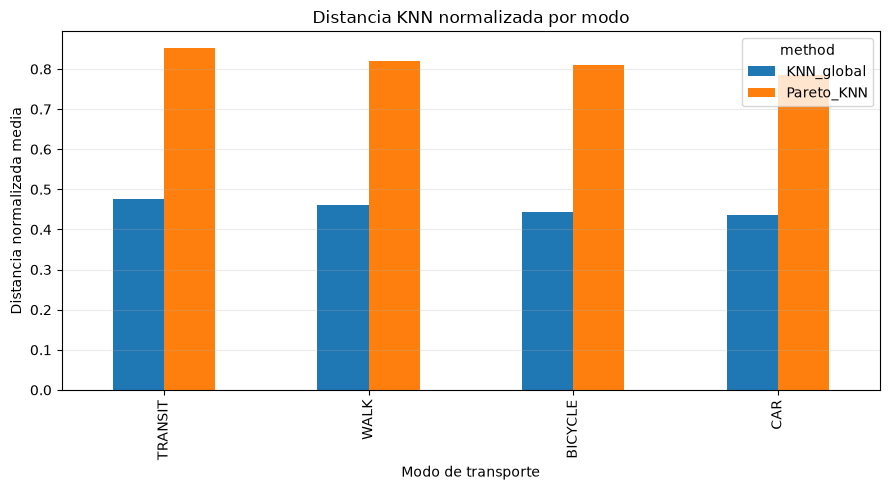

In [17]:
plot_data = (
    evaluation_default.groupby(
        ["transport_mode", "method"],
        as_index=False,
    )
    .agg(
        mean_distance=("mean_normalized_distance", "mean")
    )
)

pivot_plot = (
    plot_data.pivot(
        index="transport_mode",
        columns="method",
        values="mean_distance",
    )
    .reindex(list(EXPECTED_MODES))
)

ax = pivot_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("Distancia KNN normalizada por modo")
ax.set_xlabel("Modo de transporte")
ax.set_ylabel("Distancia normalizada media")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Interpretación del gráfico

*KNN_global* representa el límite inferior de distancia dentro del conjunto completo. *Pareto_KNN* puede igualarlo o aumentar la distancia al descartar alternativas dominadas.

Un aumento pequeño indica que la eficiencia multiobjetivo se impone con poco coste de similitud. Un aumento grande no invalida el método: muestra que, para ese modo, las alternativas más parecidas a la referencia incluyen con frecuencia zonas dominadas.


## 12.17 Solapamiento entre perfiles


In [18]:
hybrid_default = neighbors_default.loc[
    neighbors_default["method"].eq("Pareto_KNN")
].copy()

profile_overlap_rows = []

for (
    destination_id,
    transport_mode,
), group in hybrid_default.groupby(
    GROUP_KEY,
    sort=True,
):
    profile_sets = {
        profile_id: set(
            profile_group["neighbor_zone_key"].astype(str)
        )
        for profile_id, profile_group in group.groupby("profile_id")
    }

    for profile_a, profile_b in combinations(
        sorted(profile_sets),
        2,
    ):
        set_a = profile_sets[profile_a]
        set_b = profile_sets[profile_b]

        union = set_a | set_b
        intersection = set_a & set_b

        profile_overlap_rows.append(
            {
                "destination_id": destination_id,
                "transport_mode": transport_mode,
                "profile_a": profile_a,
                "profile_b": profile_b,
                "intersection": len(intersection),
                "union": len(union),
                "jaccard": (
                    len(intersection) / len(union)
                    if union
                    else np.nan
                ),
            }
        )

profile_overlap = pd.DataFrame(profile_overlap_rows)
display(profile_overlap)


,destination_id,transport_mode,profile_a,profile_b,intersection,union,jaccard
0,DEST_001,BICYCLE,balanced,price_priority,4,6,0.6667
1,DEST_001,BICYCLE,balanced,time_priority,2,8,0.2500
2,DEST_001,BICYCLE,price_priority,time_priority,1,9,0.1111
3,DEST_001,CAR,balanced,price_priority,3,7,0.4286
4,DEST_001,CAR,balanced,time_priority,0,10,0.0000
5,DEST_001,CAR,price_priority,time_priority,1,9,0.1111
6,DEST_001,TRANSIT,balanced,price_priority,4,6,0.6667
7,DEST_001,TRANSIT,balanced,time_priority,5,5,1.0000
8,DEST_001,TRANSIT,price_priority,time_priority,4,6,0.6667
9,DEST_001,WALK,balanced,price_priority,4,6,0.6667


## 12.18 Ablación del espacio de características

Se repite *k = 5* usando únicamente precio y tiempo y se compara el conjunto de vecinos con el espacio *extended*.

Si no existe ninguna característica auxiliar con cobertura suficiente, ambos espacios son idénticos y el solapamiento esperado es 1.


In [19]:
neighbors_objective, availability_objective = run_knn_experiment(
    data_df=data,
    anchors_df=anchors,
    feature_cols=OBJECTIVE_FEATURES,
    feature_space="objective_only",
    requested_k=DEFAULT_K,
)

feature_space_neighbors = pd.concat(
    [neighbors_objective, neighbors_default],
    ignore_index=True,
)

feature_space_overlap_rows = []

for (
    destination_id,
    transport_mode,
    profile_id,
    method,
), group in feature_space_neighbors.groupby(
    SCENARIO_KEY + ["method"],
    sort=True,
):
    objective_set = set(
        group.loc[
            group["feature_space"].eq("objective_only"),
            "neighbor_zone_key",
        ].astype(str)
    )

    extended_set = set(
        group.loc[
            group["feature_space"].eq("extended"),
            "neighbor_zone_key",
        ].astype(str)
    )

    union = objective_set | extended_set
    intersection = objective_set & extended_set

    feature_space_overlap_rows.append(
        {
            "destination_id": destination_id,
            "transport_mode": transport_mode,
            "profile_id": profile_id,
            "method": method,
            "objective_neighbors": len(objective_set),
            "extended_neighbors": len(extended_set),
            "intersection": len(intersection),
            "union": len(union),
            "jaccard": (
                len(intersection) / len(union)
                if union
                else np.nan
            ),
        }
    )

feature_space_overlap = pd.DataFrame(
    feature_space_overlap_rows
)

display(feature_space_overlap)


,destination_id,transport_mode,profile_id,method,objective_neighbors,extended_neighbors,intersection,union,jaccard
0,DEST_001,BICYCLE,balanced,KNN_global,5,5,4,6,0.6667
1,DEST_001,BICYCLE,balanced,Pareto_KNN,5,5,3,7,0.4286
2,DEST_001,BICYCLE,price_priority,KNN_global,5,5,1,9,0.1111
3,DEST_001,BICYCLE,price_priority,Pareto_KNN,5,5,3,7,0.4286
4,DEST_001,BICYCLE,time_priority,KNN_global,5,5,3,7,0.4286
5,DEST_001,BICYCLE,time_priority,Pareto_KNN,5,5,4,6,0.6667
6,DEST_001,CAR,balanced,KNN_global,5,5,2,8,0.2500
7,DEST_001,CAR,balanced,Pareto_KNN,5,5,4,6,0.6667
8,DEST_001,CAR,price_priority,KNN_global,5,5,0,10,0.0000
9,DEST_001,CAR,price_priority,Pareto_KNN,5,5,3,7,0.4286


## 12.19 Sensibilidad al número de vecinos


In [20]:
sensitivity_neighbor_parts = []
sensitivity_availability_parts = []

for k_value in K_VALUES:
    current_neighbors, current_availability = run_knn_experiment(
        data_df=data,
        anchors_df=anchors,
        feature_cols=EXTENDED_FEATURES,
        feature_space="extended",
        requested_k=k_value,
    )

    sensitivity_neighbor_parts.append(current_neighbors)
    sensitivity_availability_parts.append(current_availability)

neighbors_sensitivity = pd.concat(
    sensitivity_neighbor_parts,
    ignore_index=True,
)

availability_sensitivity = pd.concat(
    sensitivity_availability_parts,
    ignore_index=True,
)

evaluation_sensitivity = evaluate_neighbors(
    neighbors_sensitivity
)

sensitivity_summary = (
    evaluation_sensitivity.groupby(
        [
            "transport_mode",
            "method",
            "requested_k",
        ],
        as_index=False,
    )
    .agg(
        scenarios=("profile_id", "size"),
        mean_returned_neighbors=("returned_neighbors", "mean"),
        mean_pareto_rate_pct=("pareto_rate_pct", "mean"),
        mean_normalized_distance=("mean_normalized_distance", "mean"),
        mean_abs_price_change_pct=("mean_abs_price_change_pct", "mean"),
        mean_abs_time_change_pct=("mean_abs_time_change_pct", "mean"),
    )
)

display(sensitivity_summary)


,transport_mode,method,requested_k,scenarios,mean_returned_neighbors,mean_pareto_rate_pct,mean_normalized_distance,mean_abs_price_change_pct,mean_abs_time_change_pct
0,BICYCLE,KNN_global,3,9,3.0000,22.2222,0.4083,24.7434,80.4698
1,BICYCLE,KNN_global,5,9,4.3333,17.0370,0.4442,25.3699,104.6583
2,BICYCLE,KNN_global,7,9,5.6667,14.8148,0.4678,24.0260,123.4940
3,BICYCLE,KNN_global,10,9,7.6667,15.9259,0.4982,26.0161,132.4047
4,BICYCLE,Pareto_KNN,3,9,3.0000,100.0000,0.7438,31.2785,94.1860
5,BICYCLE,Pareto_KNN,5,9,4.3333,100.0000,0.8094,34.9965,132.3404
6,BICYCLE,Pareto_KNN,7,9,5.6667,100.0000,0.8665,37.4527,146.1099
7,BICYCLE,Pareto_KNN,10,9,7.6667,100.0000,0.9461,41.9751,183.1559
8,CAR,KNN_global,3,9,3.0000,11.1111,0.4008,19.9803,36.1575
9,CAR,KNN_global,5,9,4.3333,15.5556,0.4350,20.4820,38.5309


## 12.20 Visualización de sensibilidad a *k*


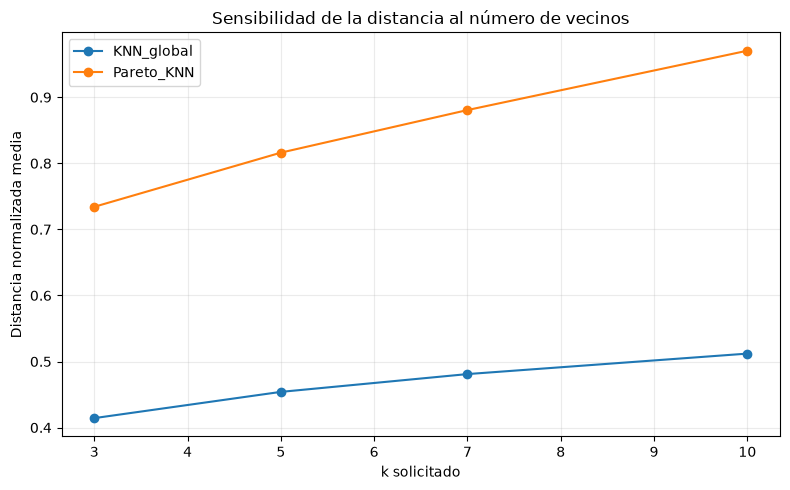

In [21]:
sensitivity_plot = (
    sensitivity_summary.groupby(
        ["requested_k", "method"],
        as_index=False,
    )
    .agg(
        mean_distance=("mean_normalized_distance", "mean")
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

for method, group in sensitivity_plot.groupby(
    "method",
    sort=True,
):
    ordered = group.sort_values("requested_k")

    ax.plot(
        ordered["requested_k"],
        ordered["mean_distance"],
        marker="o",
        label=method,
    )

ax.set_title("Sensibilidad de la distancia al número de vecinos")
ax.set_xlabel("k solicitado")
ax.set_ylabel("Distancia normalizada media")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


## 12.21 Ejemplo interpretable


In [22]:
example_anchor = (
    anchors.loc[
        anchors["profile_id"].eq("balanced")
    ]
    .sort_values(
        ["destination_id", "transport_mode"]
    )
    .iloc[0]
)

example_neighbors = (
    neighbors_default.loc[
        neighbors_default["destination_id"].astype(str).eq(
            str(example_anchor["destination_id"])
        )
        & neighbors_default["transport_mode"].astype(str).eq(
            str(example_anchor["transport_mode"])
        )
        & neighbors_default["profile_id"].eq("balanced")
    ]
    .sort_values(
        ["method", "neighbor_rank"]
    )
)

display(
    Markdown(
        f"""
**Referencia:** {example_anchor['anchor_neighborhood_name']}  
**Destino:** {example_anchor['destination_name']}  
**Modo:** {example_anchor['transport_mode_label']}  
**Perfil:** {example_anchor['profile_name']}
"""
    )
)

display(
    example_neighbors[
        [
            "method",
            "neighbor_rank",
            "neighbor_neighborhood_name",
            "neighbor_district_name",
            "neighbor_is_pareto",
            "normalized_knn_distance",
            "price_delta_pct",
            "time_delta_pct",
            "top_distance_drivers",
        ]
    ]
)



**Referencia:** Puerta del Ángel  
**Destino:** Puerta del Sol  
**Modo:** Bicicleta  
**Perfil:** Perfil equilibrado


,method,neighbor_rank,neighbor_neighborhood_name,neighbor_district_name,neighbor_is_pareto,normalized_knn_distance,price_delta_pct,time_delta_pct,top_distance_drivers
10,KNN_global,1,Moscardó,Usera,True,0.2546,-7.2923,35.1322,elevator_ratio (58.5 %); commute_daily_minutes (22.7 %); exterior_ratio (10.8 %)
11,KNN_global,2,Comillas,Carabanchel,False,0.3056,1.7903,27.2026,rooms_median (81.2 %); commute_daily_minutes (9.4 %); elevator_ratio (6.8 %)
12,KNN_global,3,Opañel,Carabanchel,True,0.3386,-13.2004,42.8414,exterior_ratio (52.9 %); elevator_ratio (19.2 %); commute_daily_minutes (19.1 %)
13,KNN_global,4,Los Cármenes,Latina,False,0.3838,-13.1582,44.8238,elevator_ratio (75.6 %); commute_daily_minutes (16.3 %); price_m2_for_recommender (6.8 %)
14,KNN_global,5,San Fermín,Usera,True,0.4307,-31.6892,88.2709,commute_daily_minutes (50.1 %); price_m2_for_recommender (31.4 %); elevator_ratio (13.4 %)
15,Pareto_KNN,1,Moscardó,Usera,True,0.2546,-7.2923,35.1322,elevator_ratio (58.5 %); commute_daily_minutes (22.7 %); exterior_ratio (10.8 %)
16,Pareto_KNN,2,Opañel,Carabanchel,True,0.3386,-13.2004,42.8414,exterior_ratio (52.9 %); elevator_ratio (19.2 %); commute_daily_minutes (19.1 %)
17,Pareto_KNN,3,San Fermín,Usera,True,0.4307,-31.6892,88.2709,commute_daily_minutes (50.1 %); price_m2_for_recommender (31.4 %); elevator_ratio (13.4 %)
18,Pareto_KNN,4,Zofío,Usera,True,0.4409,-23.4114,78.7445,exterior_ratio (41.2 %); commute_daily_minutes (38.0 %); price_m2_for_recommender (16.4 %)
19,Pareto_KNN,5,Portazgo,Puente de Vallecas,True,0.5361,-32.9641,134.0308,commute_daily_minutes (74.5 %); price_m2_for_recommender (21.9 %); exterior_ratio (3.2 %)


## 12.22 Indicadores empíricos


In [23]:
mean_strategy_jaccard = float(
    strategy_overlap["jaccard"].mean()
)

mean_profile_jaccard = float(
    profile_overlap["jaccard"].mean()
    if not profile_overlap.empty
    else np.nan
)

mean_feature_space_jaccard = float(
    feature_space_overlap["jaccard"].mean()
    if not feature_space_overlap.empty
    else np.nan
)

mean_global_pareto_rate = float(
    evaluation_default.loc[
        evaluation_default["method"].eq("KNN_global"),
        "pareto_rate_pct",
    ].mean()
)

mean_similarity_cost = float(
    strategy_comparison["similarity_cost_absolute"].mean()
)

median_similarity_cost_pct = float(
    strategy_comparison["similarity_cost_pct"].median()
)

scenarios_with_dominated_global_neighbors = int(
    (
        strategy_comparison["global_dominated_neighbors"] > 0
    ).sum()
)

full_k_scenarios = int(
    availability_default["full_k_available"].sum()
)

empirical_indicators = pd.DataFrame(
    [
        {
            "indicator": "mean_global_knn_pareto_rate_pct",
            "value": mean_global_pareto_rate,
            "interpretation": (
                "Proporción media de vecinos globales que ya son Pareto."
            ),
        },
        {
            "indicator": "scenarios_with_dominated_global_neighbors",
            "value": scenarios_with_dominated_global_neighbors,
            "interpretation": (
                "Escenarios donde KNN global recupera al menos "
                "una alternativa dominada."
            ),
        },
        {
            "indicator": "mean_similarity_cost_absolute",
            "value": mean_similarity_cost,
            "interpretation": (
                "Aumento medio de distancia normalizada "
                "al restringir KNN al frente."
            ),
        },
        {
            "indicator": "median_similarity_cost_pct",
            "value": median_similarity_cost_pct,
            "interpretation": (
                "Coste relativo mediano de la restricción Pareto."
            ),
        },
        {
            "indicator": "mean_strategy_jaccard",
            "value": mean_strategy_jaccard,
            "interpretation": (
                "Solapamiento medio entre KNN global y Pareto+KNN."
            ),
        },
        {
            "indicator": "mean_profile_jaccard",
            "value": mean_profile_jaccard,
            "interpretation": (
                "Solapamiento medio de vecinos Pareto entre perfiles."
            ),
        },
        {
            "indicator": "mean_feature_space_jaccard",
            "value": mean_feature_space_jaccard,
            "interpretation": (
                "Solapamiento medio entre espacio objetivo y extendido."
            ),
        },
        {
            "indicator": "full_k_scenarios",
            "value": full_k_scenarios,
            "interpretation": (
                f"Escenarios que pueden devolver los {DEFAULT_K} vecinos "
                "en ambas estrategias."
            ),
        },
    ]
)

display(empirical_indicators)


,indicator,value,interpretation
0,mean_global_knn_pareto_rate_pct,17.7778,Proporción media de vecinos globales que ya son Pareto.
1,scenarios_with_dominated_global_neighbors,36.0000,Escenarios donde KNN global recupera al menos una alternativa dominada.
2,mean_similarity_cost_absolute,0.3621,Aumento medio de distancia normalizada al restringir KNN al frente.
3,median_similarity_cost_pct,70.8479,Coste relativo mediano de la restricción Pareto.
4,mean_strategy_jaccard,0.1110,Solapamiento medio entre KNN global y Pareto+KNN.
5,mean_profile_jaccard,0.4305,Solapamiento medio de vecinos Pareto entre perfiles.
6,mean_feature_space_jaccard,0.4878,Solapamiento medio entre espacio objetivo y extendido.
7,full_k_scenarios,24.0000,Escenarios que pueden devolver los 5 vecinos en ambas estrategias.


### Interpretación de los indicadores

Los indicadores anteriores son descriptivos. No se modifica el algoritmo para conseguir determinados valores.

- Una tasa Pareto alta en *KNN_global* indica que la similitud local ya tiende a recuperar soluciones eficientes.
- Un coste de similitud alto indica que el filtro Pareto es restrictivo para ese conjunto.
- Un Jaccard bajo entre perfiles muestra que la personalización también modifica el entorno local de alternativas.
- Un Jaccard bajo entre espacios de características indica que las variables residenciales cambian de forma apreciable la noción de “barrio parecido”.


## 12.23 Validaciones estructurales


In [24]:
validation_rows = []


def add_validation(
    validation_id: str,
    description: str,
    passed: bool,
    detail: str,
) -> None:
    validation_rows.append(
        {
            "validation_id": validation_id,
            "validation_type": "structural",
            "description": description,
            "passed": bool(passed),
            "detail": detail,
        }
    )


add_validation(
    "pipeline11_contract",
    "Todas las validaciones estructurales heredadas del notebook 11 están superadas.",
    structural_pipeline_rows["passed"].all(),
    (
        f"Superadas: {int(structural_pipeline_rows['passed'].sum())}/"
        f"{len(structural_pipeline_rows)}"
    ),
)

add_validation(
    "unique_alternatives",
    "No hay alternativas barrio-destino-modo duplicadas.",
    duplicate_alternatives == 0,
    f"Duplicados: {duplicate_alternatives}",
)

add_validation(
    "exact_transport_modes",
    "Están presentes exactamente los cuatro modos esperados.",
    observed_modes == set(EXPECTED_MODES),
    f"Modos: {sorted(observed_modes)}",
)

add_validation(
    "complete_destination_mode_matrix",
    "Existen las 12 combinaciones destino-modo.",
    len(group_catalog) == 12,
    f"Esperadas: 12; presentes: {len(group_catalog)}",
)

add_validation(
    "core_values_complete",
    "Precio, tiempo y normalizaciones están completos.",
    core_missing == 0,
    f"Filas problemáticas: {core_missing}",
)

add_validation(
    "positive_core_values",
    "Precio y tiempo son estrictamente positivos.",
    nonpositive_price == 0 and nonpositive_time == 0,
    (
        f"Precios no positivos: {nonpositive_price}; "
        f"tiempos no positivos: {nonpositive_time}"
    ),
)

add_validation(
    "pareto_reproduction",
    "El Pareto recalculado coincide exactamente con el notebook 08.",
    pareto_mismatches == 0,
    f"Discrepancias: {pareto_mismatches}",
)

add_validation(
    "profile_contract",
    "Los tres perfiles y sus pesos coinciden con el notebook 09.",
    (
        set(profiles["profile_id"].astype(str))
        == set(EXPECTED_PROFILE_WEIGHTS)
        and profile_contract["passed"].all()
    ),
    (
        f"Perfiles válidos: "
        f"{int(profile_contract['passed'].sum())}/"
        f"{len(profile_contract)}"
    ),
)

expected_anchor_rows = (
    len(group_catalog) * len(EXPECTED_PROFILE_WEIGHTS)
)

add_validation(
    "anchor_coverage",
    "Existe una referencia para cada combinación destino-modo-perfil.",
    len(anchors) == expected_anchor_rows,
    (
        f"Esperadas: {expected_anchor_rows}; "
        f"presentes: {len(anchors)}"
    ),
)

anchor_duplicates = int(
    anchors.duplicated(subset=SCENARIO_KEY).sum()
)

add_validation(
    "unique_anchors",
    "No hay referencias duplicadas por escenario.",
    anchor_duplicates == 0,
    f"Duplicados: {anchor_duplicates}",
)

add_validation(
    "anchors_are_pareto",
    "Todas las referencias personalizadas pertenecen al frente.",
    anchors["anchor_is_pareto"].all(),
    (
        f"Pareto: {int(anchors['anchor_is_pareto'].sum())}/"
        f"{len(anchors)}"
    ),
)

add_validation(
    "anchor_reconstruction",
    "Las referencias coinciden con una reconstrucción independiente del ranking del notebook 09.",
    anchors["anchor_matches_independent_reconstruction"].all(),
    (
        f"Coincidencias: "
        f"{int(anchors['anchor_matches_independent_reconstruction'].sum())}/"
        f"{len(anchors)}"
    ),
)

self_neighbors = int(
    (
        neighbors_default["anchor_zone_key"].astype(str)
        == neighbors_default["neighbor_zone_key"].astype(str)
    ).sum()
)

add_validation(
    "no_self_neighbors",
    "Ninguna referencia aparece como vecina de sí misma.",
    self_neighbors == 0,
    f"Casos: {self_neighbors}",
)

neighbor_duplicates = int(
    neighbors_default.duplicated(
        subset=(
            SCENARIO_KEY
            + [
                "feature_space",
                "method",
                "requested_k",
                "neighbor_zone_key",
            ]
        )
    ).sum()
)

add_validation(
    "unique_neighbors_per_list",
    "No hay vecinos duplicados dentro de una lista.",
    neighbor_duplicates == 0,
    f"Duplicados: {neighbor_duplicates}",
)

negative_distances = int(
    (
        neighbors_default["normalized_knn_distance"]
        < -FLOAT_TOL
    ).sum()
)

add_validation(
    "nonnegative_distances",
    "Todas las distancias KNN son no negativas.",
    negative_distances == 0,
    f"Casos: {negative_distances}",
)

rank_checks = []
distance_order_checks = []
returned_k_checks = []

for _, group in neighbors_default.groupby(
    SCENARIO_KEY
    + ["feature_space", "method", "requested_k"],
    sort=True,
):
    ordered = group.sort_values("neighbor_rank")

    expected_ranks = list(
        range(1, len(ordered) + 1)
    )

    rank_checks.append(
        ordered["neighbor_rank"].tolist()
        == expected_ranks
    )

    distance_order_checks.append(
        ordered["normalized_knn_distance"].is_monotonic_increasing
    )

    returned_k_checks.append(
        len(ordered)
        == int(ordered["comparison_k"].iloc[0])
    )

add_validation(
    "consecutive_ranks",
    "Los rankings empiezan en 1 y son consecutivos.",
    all(rank_checks),
    f"Listas comprobadas: {len(rank_checks)}",
)

add_validation(
    "distance_order",
    "Las listas están ordenadas por distancia no decreciente.",
    all(distance_order_checks),
    f"Listas comprobadas: {len(distance_order_checks)}",
)

add_validation(
    "matched_k_returned",
    "Cada estrategia devuelve exactamente el comparison_k del escenario.",
    all(returned_k_checks),
    f"Listas comprobadas: {len(returned_k_checks)}",
)

hybrid_nonpareto = int(
    (
        ~neighbors_default.loc[
            neighbors_default["method"].eq("Pareto_KNN"),
            "neighbor_is_pareto",
        ]
    ).sum()
)

add_validation(
    "hybrid_only_pareto",
    "Pareto_KNN no devuelve alternativas dominadas.",
    hybrid_nonpareto == 0,
    f"Violaciones: {hybrid_nonpareto}",
)

unfair_k = int(
    (
        strategy_comparison["global_returned_neighbors"]
        != strategy_comparison["hybrid_returned_neighbors"]
    ).sum()
)

add_validation(
    "fair_strategy_comparison",
    "KNN global y Pareto_KNN se comparan con el mismo número de vecinos.",
    unfair_k == 0,
    f"Escenarios desiguales: {unfair_k}",
)

negative_similarity_cost = int(
    (
        strategy_comparison["similarity_cost_absolute"]
        < -1e-9
    ).sum()
)

add_validation(
    "subset_distance_property",
    "Restringir candidatos a Pareto no produce menor distancia media que buscar en el conjunto completo.",
    negative_similarity_cost == 0,
    f"Violaciones numéricas: {negative_similarity_cost}",
)

deterministic_repeat, _ = run_knn_experiment(
    data_df=data,
    anchors_df=anchors,
    feature_cols=EXTENDED_FEATURES,
    feature_space="extended",
    requested_k=DEFAULT_K,
)

deterministic_columns = (
    SCENARIO_KEY
    + [
        "method",
        "neighbor_rank",
        "neighbor_zone_key",
        "normalized_knn_distance",
    ]
)

deterministic_a = (
    neighbors_default[deterministic_columns]
    .sort_values(deterministic_columns[:-1])
    .reset_index(drop=True)
)

deterministic_b = (
    deterministic_repeat[deterministic_columns]
    .sort_values(deterministic_columns[:-1])
    .reset_index(drop=True)
)

deterministic_ok = (
    deterministic_a[deterministic_columns[:-1]].equals(
        deterministic_b[deterministic_columns[:-1]]
    )
    and np.allclose(
        deterministic_a["normalized_knn_distance"],
        deterministic_b["normalized_knn_distance"],
        rtol=0.0,
        atol=1e-12,
    )
)

add_validation(
    "determinism",
    "La misma configuración reproduce exactamente vecinos y distancias.",
    deterministic_ok,
    f"Filas comparadas: {len(deterministic_a)}",
)

expected_sensitivity_scenarios = (
    expected_anchor_rows * len(K_VALUES)
)

observed_sensitivity_scenarios = (
    availability_sensitivity[
        SCENARIO_KEY + ["requested_k"]
    ]
    .drop_duplicates()
    .shape[0]
)

add_validation(
    "sensitivity_coverage",
    "La sensibilidad cubre todos los escenarios para todos los valores de k.",
    observed_sensitivity_scenarios == expected_sensitivity_scenarios,
    (
        f"Esperados: {expected_sensitivity_scenarios}; "
        f"presentes: {observed_sensitivity_scenarios}"
    ),
)

validation_report = pd.DataFrame(validation_rows)
display(validation_report)

failed_validations = validation_report.loc[
    ~validation_report["passed"]
]

if not failed_validations.empty:
    display(Markdown("### Validaciones no superadas"))
    display(failed_validations)
    raise AssertionError(
        "El notebook 12 no ha superado todas "
        "las validaciones estructurales."
    )

print(
    "Todas las validaciones estructurales "
    "del notebook 12 se han superado correctamente."
)


,validation_id,validation_type,description,passed,detail
0,pipeline11_contract,structural,Todas las validaciones estructurales heredadas del notebook 11 están superadas.,True,Superadas: 15/15
1,unique_alternatives,structural,No hay alternativas barrio-destino-modo duplicadas.,True,Duplicados: 0
2,exact_transport_modes,structural,Están presentes exactamente los cuatro modos esperados.,True,"Modos: ['BICYCLE', 'CAR', 'TRANSIT', 'WALK']"
3,complete_destination_mode_matrix,structural,Existen las 12 combinaciones destino-modo.,True,Esperadas: 12; presentes: 12
4,core_values_complete,structural,"Precio, tiempo y normalizaciones están completos.",True,Filas problemáticas: 0
5,positive_core_values,structural,Precio y tiempo son estrictamente positivos.,True,Precios no positivos: 0; tiempos no positivos: 0
6,pareto_reproduction,structural,El Pareto recalculado coincide exactamente con el notebook 08.,True,Discrepancias: 0
7,profile_contract,structural,Los tres perfiles y sus pesos coinciden con el notebook 09.,True,Perfiles válidos: 3/3
8,anchor_coverage,structural,Existe una referencia para cada combinación destino-modo-perfil.,True,Esperadas: 36; presentes: 36
9,unique_anchors,structural,No hay referencias duplicadas por escenario.,True,Duplicados: 0


Todas las validaciones estructurales del notebook 12 se han superado correctamente.


## 12.24 Síntesis automática de resultados


In [25]:
hybrid_default_eval = evaluation_default.loc[
    evaluation_default["method"].eq("Pareto_KNN")
]

display(
    Markdown(
        f"""
### Resumen de la extensión híbrida

- Alternativas de entrada: **{len(data):,}**
- Barrios con alternativas válidas: **{data['zone_key'].nunique()}**
- Grupos destino–modo: **{len(group_catalog)}**
- Escenarios destino–modo–perfil: **{len(anchors)}**
- Variables del espacio KNN extendido: **{len(EXTENDED_FEATURES)}**
- Vecinos solicitados por escenario: **{DEFAULT_K}**
- Escenarios con `k={DEFAULT_K}` completo: **{full_k_scenarios}/{len(availability_default)}**
- Tasa Pareto media de KNN global: **{mean_global_pareto_rate:.2f} %**
- Tasa Pareto de Pareto+KNN: **{100 * hybrid_default_eval['pareto_rate'].mean():.2f} %**
- Escenarios donde KNN global recupera alguna alternativa dominada: **{scenarios_with_dominated_global_neighbors}/{len(strategy_comparison)}**
- Coste medio absoluto de similitud al imponer Pareto: **{mean_similarity_cost:.4f}**
- Coste relativo mediano de similitud: **{median_similarity_cost_pct:.2f} %**
- Jaccard medio entre estrategias: **{mean_strategy_jaccard:.3f}**
- Jaccard medio entre perfiles: **{mean_profile_jaccard:.3f}**
- Jaccard medio entre espacio objetivo y extendido: **{mean_feature_space_jaccard:.3f}**
- Validaciones estructurales superadas: **{int(validation_report['passed'].sum())}/{len(validation_report)}**
"""
    )
)



### Resumen de la extensión híbrida

- Alternativas de entrada: **1,457**
- Barrios con alternativas válidas: **129**
- Grupos destino–modo: **12**
- Escenarios destino–modo–perfil: **36**
- Variables del espacio KNN extendido: **6**
- Vecinos solicitados por escenario: **5**
- Escenarios con `k=5` completo: **24/36**
- Tasa Pareto media de KNN global: **17.78 %**
- Tasa Pareto de Pareto+KNN: **100.00 %**
- Escenarios donde KNN global recupera alguna alternativa dominada: **36/36**
- Coste medio absoluto de similitud al imponer Pareto: **0.3621**
- Coste relativo mediano de similitud: **70.85 %**
- Jaccard medio entre estrategias: **0.111**
- Jaccard medio entre perfiles: **0.430**
- Jaccard medio entre espacio objetivo y extendido: **0.488**
- Validaciones estructurales superadas: **23/23**


## 12.25 Exportación de resultados


In [26]:
final_summary = pd.Series(
    {
        "input_alternatives": len(data),
        "neighborhoods": data["zone_key"].nunique(),
        "destinations": data["destination_id"].nunique(),
        "transport_modes": data["transport_mode"].nunique(),
        "destination_mode_groups": len(group_catalog),
        "profiles": len(profiles),
        "anchor_scenarios": len(anchors),
        "extended_features": len(EXTENDED_FEATURES),
        "default_k": DEFAULT_K,
        "default_full_k_scenarios": full_k_scenarios,
        "default_scenarios": len(availability_default),
        "global_knn_mean_pareto_rate_pct": mean_global_pareto_rate,
        "hybrid_knn_mean_pareto_rate_pct": (
            100 * hybrid_default_eval["pareto_rate"].mean()
        ),
        "scenarios_with_dominated_global_neighbors": (
            scenarios_with_dominated_global_neighbors
        ),
        "mean_similarity_cost_absolute": mean_similarity_cost,
        "median_similarity_cost_pct": median_similarity_cost_pct,
        "mean_strategy_jaccard": mean_strategy_jaccard,
        "mean_profile_jaccard": mean_profile_jaccard,
        "mean_feature_space_jaccard": mean_feature_space_jaccard,
        "structural_validations_passed": int(
            validation_report["passed"].sum()
        ),
        "structural_validations_total": len(validation_report),
    },
    name="value",
).to_frame()

EXPORTS = {
    OUTPUT_PATHS["candidate_pool_summary"]: candidate_pool_summary,
    OUTPUT_PATHS["feature_audit"]: feature_audit,
    OUTPUT_PATHS["anchors"]: anchors,
    OUTPUT_PATHS["availability"]: availability_default,
    OUTPUT_PATHS["neighbors_default"]: neighbors_default,
    OUTPUT_PATHS["evaluation_default"]: evaluation_default,
    OUTPUT_PATHS["strategy_comparison"]: strategy_comparison,
    OUTPUT_PATHS["strategy_overlap"]: strategy_overlap,
    OUTPUT_PATHS["mode_summary"]: mode_summary,
    OUTPUT_PATHS["profile_overlap"]: profile_overlap,
    OUTPUT_PATHS["feature_space_overlap"]: feature_space_overlap,
    OUTPUT_PATHS["sensitivity_neighbors"]: neighbors_sensitivity,
    OUTPUT_PATHS["sensitivity_summary"]: sensitivity_summary,
    OUTPUT_PATHS["empirical_indicators"]: empirical_indicators,
    OUTPUT_PATHS["validation_report"]: validation_report,
    OUTPUT_PATHS["final_summary"]: final_summary,
}

for path, frame in EXPORTS.items():
    frame.to_csv(
        path,
        index=(path == OUTPUT_PATHS["final_summary"]),
        encoding="utf-8-sig",
    )

missing_exports = [
    path for path in EXPORTS
    if not path.exists()
]

if missing_exports:
    raise FileNotFoundError(
        "No se han generado todos los resultados esperados: "
        f"{missing_exports}"
    )

print("Archivos generados correctamente:")

for path in EXPORTS:
    print("-", path.relative_to(PROJECT_ROOT))


Archivos generados correctamente:
- data/results/knn12_multimodal_candidate_pool_summary.csv
- data/results/knn12_multimodal_feature_audit.csv
- data/results/knn12_multimodal_anchors.csv
- data/results/knn12_multimodal_availability_audit.csv
- data/results/knn12_multimodal_neighbors_k5.csv
- data/results/knn12_multimodal_evaluation_k5.csv
- data/results/knn12_multimodal_strategy_comparison.csv
- data/results/knn12_multimodal_strategy_overlap.csv
- data/results/knn12_multimodal_mode_summary.csv
- data/results/knn12_multimodal_profile_overlap.csv
- data/results/knn12_multimodal_feature_space_overlap.csv
- data/results/knn12_multimodal_neighbors_sensitivity.csv
- data/results/knn12_multimodal_sensitivity_summary.csv
- data/results/knn12_multimodal_empirical_indicators.csv
- data/results/knn12_multimodal_validation_report.csv
- data/results/knn12_multimodal_summary.csv


## 12.27 Limitaciones

Esta extensión debe interpretarse dentro de su alcance:

- KNN es un método de similitud, no un modelo causal ni predictivo.
- La distancia depende de las variables disponibles y de la estandarización elegida.
- Las características de vivienda son agregados por barrio, no atributos de una vivienda concreta.
- La imputación con mediana se utiliza únicamente para características auxiliares; **precio y tiempo no se imputan**.
- Una distancia pequeña no garantiza preferencia subjetiva del usuario.
- No se incorporan todavía amenidades urbanas, seguridad, ruido, zonas verdes, colegios u otros atributos cualitativos.
- Las distancias se calculan por *destino–modo*; no deben interpretarse como una escala absoluta universal entre grupos.
- *Pareto_KNN* devuelve únicamente soluciones Pareto por definición. Es una garantía estructural, no evidencia aprendida.
- La evaluación es offline y no dispone de etiquetas de “recomendación correcta” obtenidas de usuarios reales.


## 12.28 Conclusión

El notebook incorpora KNN como **capa auxiliar y explicable** sobre el recomendador multimodal validado.

La extensión conserva tres principios:

1. **Pareto sigue siendo el núcleo multiobjetivo**, porque define qué alternativas son eficientes en precio y tiempo.
2. **Las preferencias del usuario siguen determinando la referencia**, mediante los mismos tres perfiles de los notebooks 09–11.
3. **KNN aporta una función distinta**, recuperando barrios similares dentro de la misma combinación destino–modo.

La comparación con KNN global, la sensibilidad a `k`, el análisis por modo, el solapamiento entre perfiles y la ablación del espacio de características permiten evaluar esta capa sin atribuirle propiedades que no tiene.

Si todas las validaciones estructurales se superan, el notebook queda preparado para documentarse como una extensión experimental del recomendador y para alimentar una interfaz que muestre no solo una zona recomendada, sino también alternativas similares y eficientes.


In [27]:
display(
    Markdown(
        f"""
### Resultado final

**Todas las validaciones estructurales del notebook 12 se han superado correctamente.**

Se han analizado **{len(anchors)} escenarios destino–modo–perfil** sobre **{len(data):,} alternativas** y **{len(group_catalog)} grupos destino–modo**.

**Notebook 12 multimodal finalizado correctamente.**
"""
    )
)



### Resultado final

**Todas las validaciones estructurales del notebook 12 se han superado correctamente.**

Se han analizado **36 escenarios destino–modo–perfil** sobre **1,457 alternativas** y **12 grupos destino–modo**.

**Notebook 12 multimodal finalizado correctamente.**
